# **Experiment A-08 - Lower Trajectory Differentiation Length**

## **🔴 Context**

- `n_steps` = step number of differentiated trajectory
- `n_gap` = step distance between two differentiated trajectories
- Unti now, `n_step = 10` and `n_gap = 50`.
- `n_steps + n_gap = 60`, the subexperiments here always add up to `60` (e.g. `2+58` or `5+55`)

---

## **🟡 Experiment Questions**

#### **Q1 - Does lower n_steps lead to same skill?**

XXX

#### **Q2 - Does higher n_steps lead to same stability?**

XXX

---


## **🟢 Short Result**
#### XXX


---

## **0. Setup**

In [1]:
# Loading packages
using Revise
using NeuralParam
using CairoMakie
using Statistics

In [ ]:
# Define experiment
EXP = "exp_A_08_nsteps_lower";

## **1. Training**

In [3]:
# Define notebook picture scaling
NB_TRAIN = (; size = (900, 600));

In [ ]:
# Define schemes, labels, colors and plotting steps
SCHEMES = ["Steps1_Gap59", "Steps2_Gap58", "Steps5_Gap55"]
LABELS = ["S1 G59", "S2 G58", "S5 G55"]
COLORS = [JL_RED, JL_BLUE, JL_GREEN]
STEPS = 100:500;

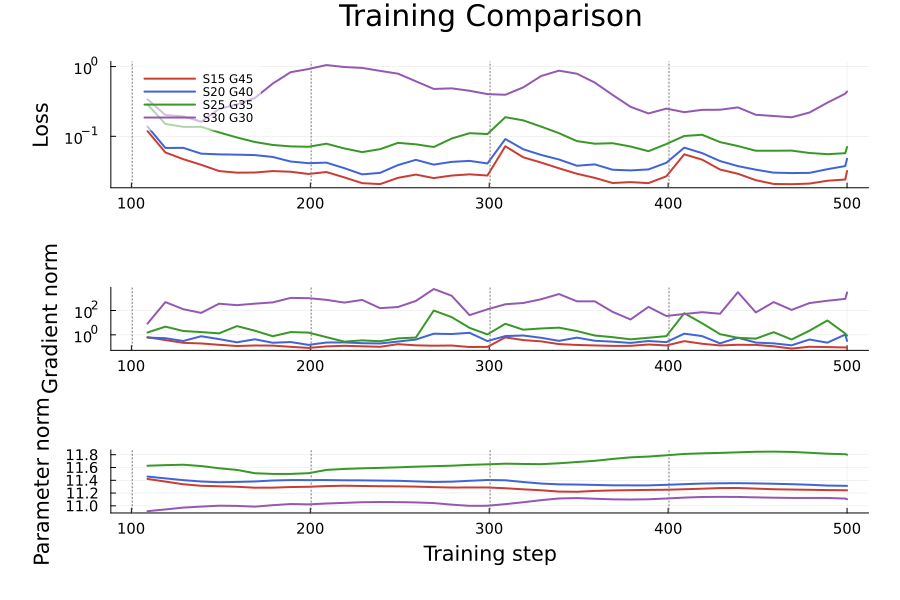

In [7]:
# Plot training comparison
plot_training_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

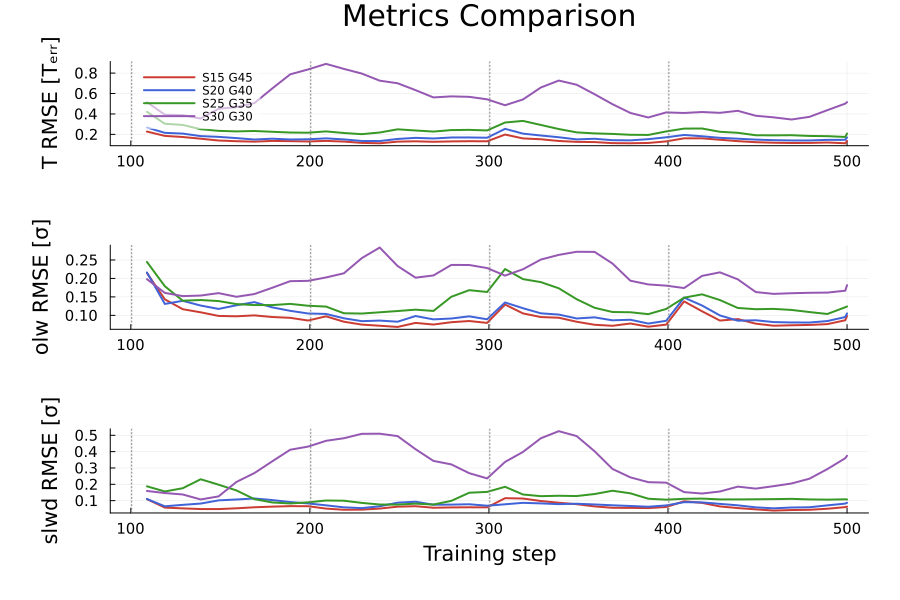

In [8]:
# Training metrics comparison
plot_metrics_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

## **2. Rollouts**

In [9]:
# Define notebook picture scaling
NB_ROLLOUT = (; size = (1200, 400));

In [ ]:
# Load NeuralLW with default n_steps (n_steps=10, n_gap=50) rollouts
EXP_H2W32 = "exp_A_06_arch_smaller";
skill_H2W32 = collect_rollouts(EXP_H2W32, ["NLW_H1_W64_skill"]);
stab_H2W32 = collect_rollouts(EXP_H2W32, ["NLW_H1_W64_stab"]);

In [ ]:
# Load different n_steps rollouts
SKILL_NAMES = [
    "OBLW_skill",
    "Steps1_Gap59_skill",
    "Steps2_Gap58_skill",
    "Steps5_Gap55_skill",
]
STAB_NAMES = replace.(SKILL_NAMES, "skill" => "stab")

skill_arch = collect_rollouts(EXP, SKILL_NAMES);
stab_arch = collect_rollouts(EXP, STAB_NAMES);

In [ ]:
# Merge rollouts and define labels and colors
skill = merge(skill_H2W32, skill_arch);
stab = merge(stab_H2W32, stab_arch);

LABELS = ["S10 Gap50", "OBLW", "S1 G59", "S2 G58", "S5 G55"]
COLORS = [:black, :grey, JL_BLUE, JL_GREEN, JL_RED];

### 2.1. Skill (31 days)

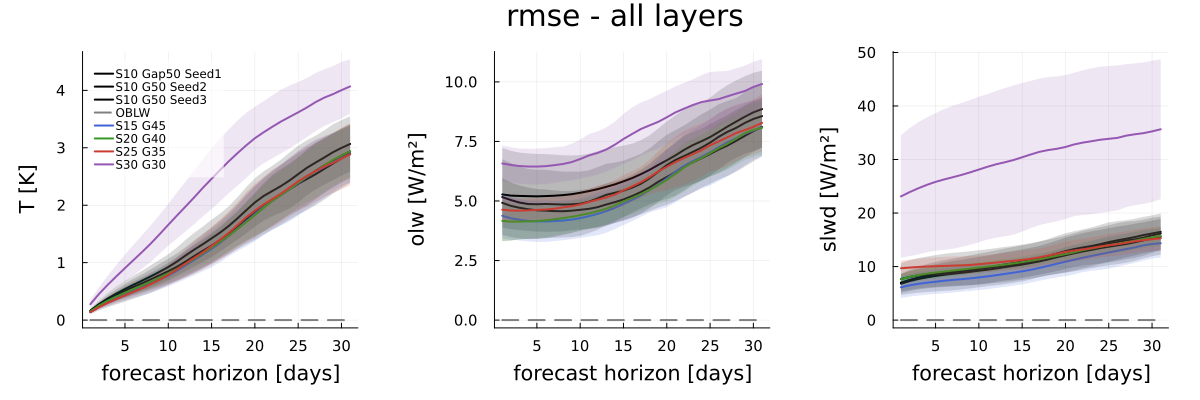

In [13]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

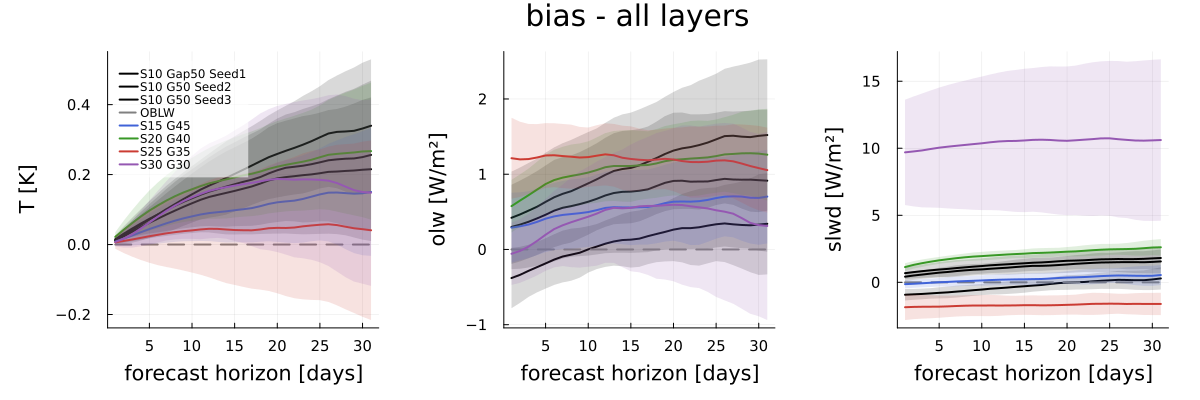

In [14]:
# Plot bias comparison
plot_rollout(rollouts = skill, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

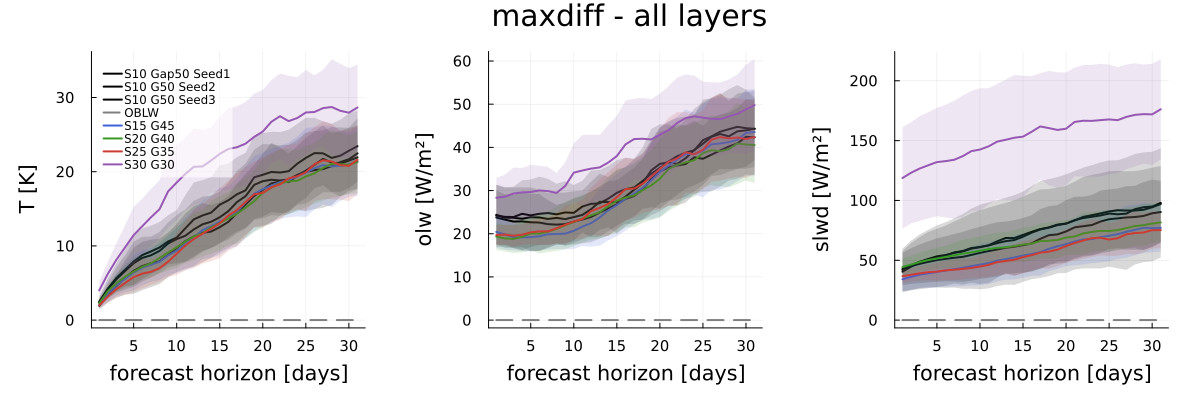

In [15]:
# Plot maxdiff comparison
plot_rollout(rollouts = skill, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

### 2.2. Stability (365 days)

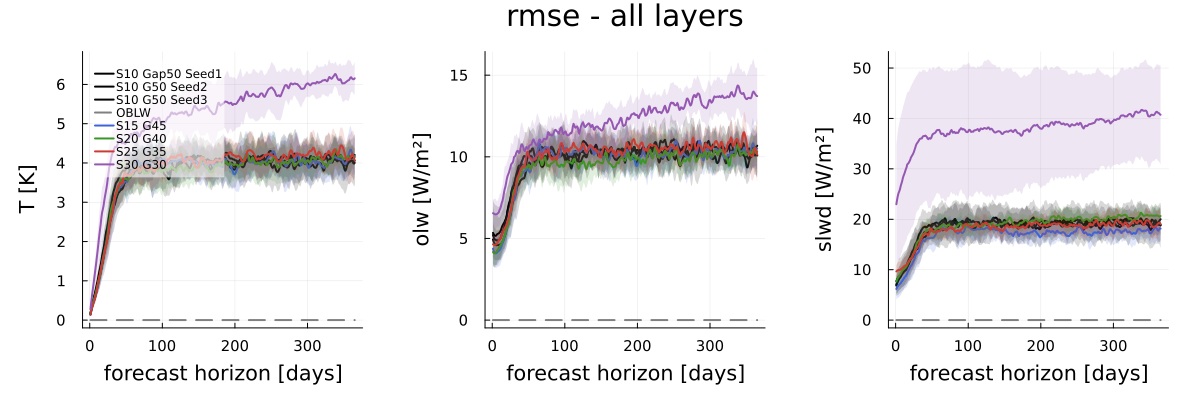

In [22]:
# Plot rmse comparison
plot_rollout(rollouts = stab, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

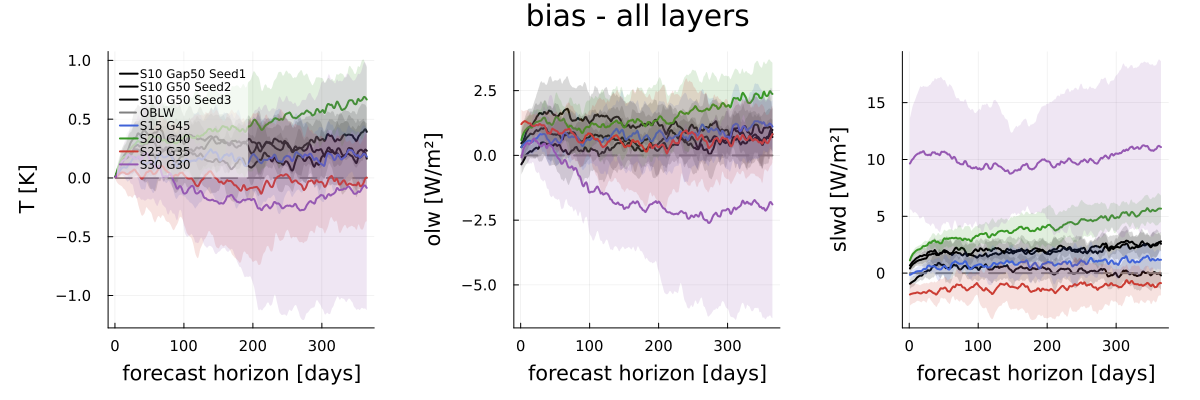

In [23]:
# Plot bias comparison
plot_rollout(rollouts = stab, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

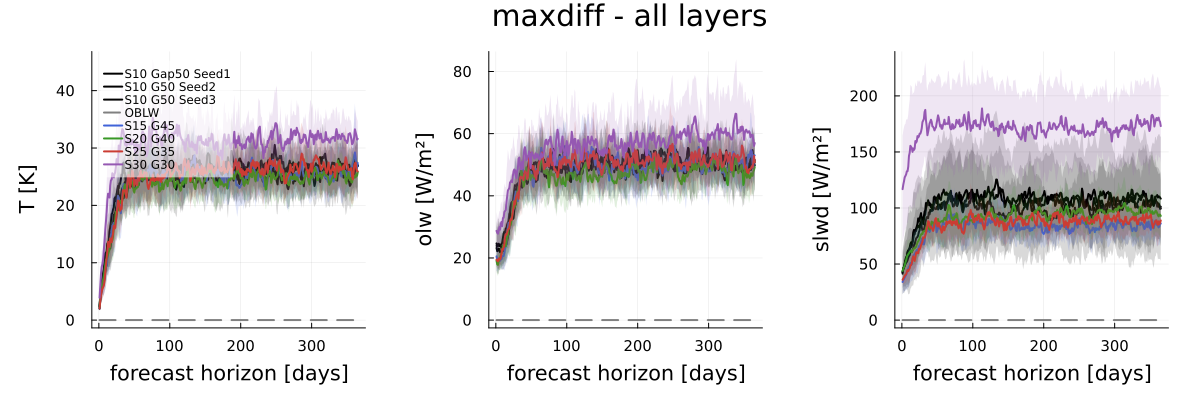

In [24]:
# Plot maxdiff comparison
plot_rollout(rollouts = stab, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)